# 04 — Graph construction

We will produce a `torch_geometric.data.Data` object compatible with
`backend.perception.structural.gat_model.GraphEncoder`.

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
import yfinance as yf
from torch_geometric.data import Data

from backend.config.constants import (
    NUM_SECTORS,
    SECTORS,
    TARGET_TICKERS,
    TICKER_TO_SECTOR,
)

plt.style.use("dark_background")
COLORS = {
    "primary": "#4FC3F7",
    "success": "#66BB6A",
    "danger": "#EF5350",
    "warning": "#FFA726",
    "neutral": "#B0BEC5",
}

UNIVERSE = sorted(TARGET_TICKERS)
N = len(UNIVERSE)

/home/pyros05/Escritorio/lumina_project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Pull daily prices

In [2]:
df = yf.download(
    UNIVERSE,
    period="2y",
    interval="1d",
    auto_adjust=True,
    progress=False,
)
close = df["Close"]
returns = np.log(close / close.shift(1)).dropna()

## 2. Node features

32-dim node feature vector composition:
  - sector one-hot:   NUM_SECTORS dims
  - log market cap:   1 dim (simulated)
  - realised vol:     1 dim
  - beta vs SPY:      1 dim
  - reserved zeros:   pad to 32

In [3]:
sector_idx = {s: i for i, s in enumerate(SECTORS)}
spy_ret = returns["SPY"] if "SPY" in returns.columns else returns.iloc[:, 0]
features = np.zeros((N, 32), dtype=np.float32)

for i, t in enumerate(UNIVERSE):
    sec = TICKER_TO_SECTOR.get(t, "tech")
    if sec in sector_idx:
        features[i, sector_idx[sec]] = 1.0
    # Simulated log market cap [10, 13]
    features[i, NUM_SECTORS] = np.random.uniform(10, 13) / 13.0
    features[i, NUM_SECTORS + 1] = float(returns[t].std() * np.sqrt(252))
    cov = float(returns[t].cov(spy_ret))
    var_spy = float(spy_ret.var())
    features[i, NUM_SECTORS + 2] = cov / var_spy if var_spy > 0 else 0.0

print("Feature matrix:", features.shape)

Feature matrix: (50, 32)


## 3. Edges: Static (Supply Chain) + Dynamic (Correlation)

We manually define some supply-chain relationships for this demo.

In [4]:
STATIC_EDGES = [
    ("NVDA", "AAPL"),
    ("NVDA", "MSFT"),
    ("NVDA", "AMZN"),
    ("AMD", "MSFT"),
    ("AVGO", "AAPL"),
    ("MA", "V"),
    ("CVX", "XOM"),
    ("BAC", "JPM"),
]

ticker_to_idx = {t: i for i, t in enumerate(UNIVERSE)}
edges, edge_attrs = [], []

# 1. Add static edges
for src, tgt in STATIC_EDGES:
    if src in ticker_to_idx and tgt in ticker_to_idx:
        i, j = ticker_to_idx[src], ticker_to_idx[tgt]
        edges.append([i, j])
        # [r, |r|, is_supply_chain=1, weight]
        edge_attrs.append([0.0, 0.0, 1.0, 0.8])

# 2. Add dynamic correlation edges (|r| > 0.6)
corr = returns.corr().to_numpy()
for i in range(N):
    for j in range(N):
        if i == j:
            continue
        r = float(corr[i, j])
        if abs(r) > 0.6:
            # Only add if not already a static edge
            if not any(e == [i, j] for e in edges):
                edges.append([i, j])
                edge_attrs.append([r, abs(r), 0.0, max(r, 0.0)])

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
edge_attr = torch.tensor(edge_attrs, dtype=torch.float32)
print(f"Total Edges: {edge_index.shape[1]}")

Total Edges: 137


## 4. Visualisation: Market Graph

/tmp/ipykernel_43534/2172719529.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(unique_sectors))


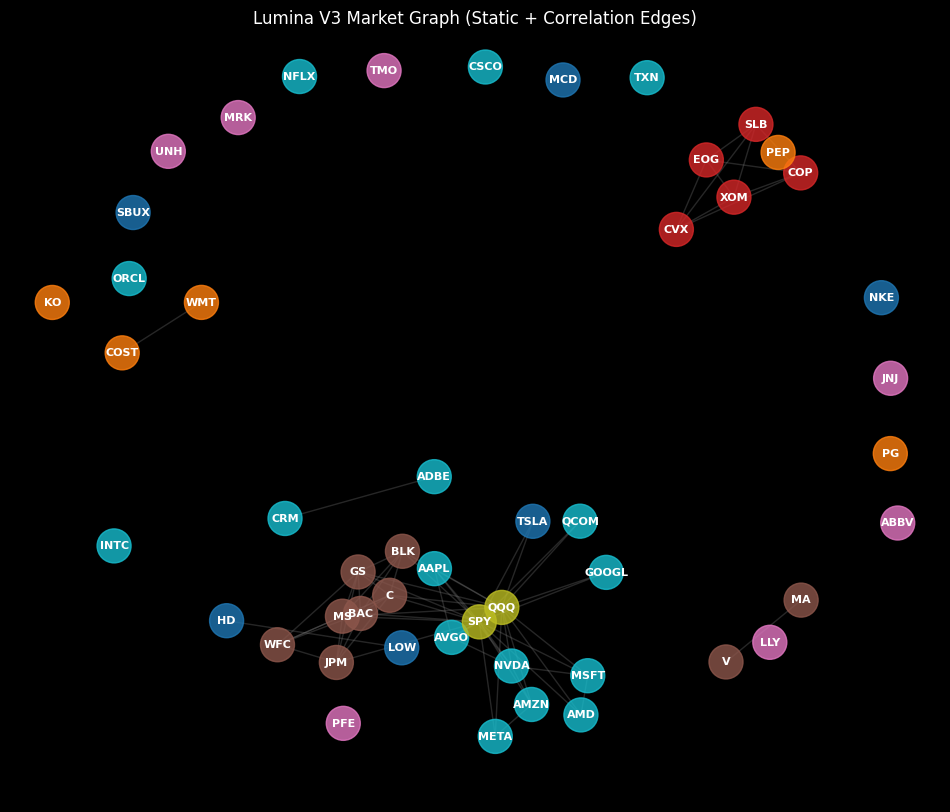

In [5]:
def plot_market_graph(edge_idx, tickers):
    G = nx.Graph()
    G.add_nodes_from(tickers)
    for i in range(edge_idx.shape[1]):
        u, v = tickers[edge_idx[0, i]], tickers[edge_idx[1, i]]
        G.add_edge(u, v)

    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G, k=0.5, iterations=50)

    # Color nodes by sector
    unique_sectors = sorted(list(set(TICKER_TO_SECTOR.values())))
    color_map = plt.cm.get_cmap("tab10", len(unique_sectors))
    node_colors = [
        color_map(unique_sectors.index(TICKER_TO_SECTOR.get(t, "tech"))) for t in tickers
    ]

    nx.draw_networkx_nodes(G, pos, node_size=600, node_color=node_colors, alpha=0.8)
    nx.draw_networkx_labels(G, pos, font_size=8, font_color="white", font_weight="bold")
    nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color="gray")

    plt.title("Lumina V3 Market Graph (Static + Correlation Edges)")
    plt.axis("off")
    plt.show()


plot_market_graph(edge_index, UNIVERSE)

## 5. Smoke-run the encoder

In [6]:
from backend.perception.structural.gat_model import GraphEncoder

data = Data(x=torch.from_numpy(features), edge_index=edge_index, edge_attr=edge_attr)
gnn = GraphEncoder(node_feat_dim=32, hidden_dim=64, output_dim=32)
z = gnn(data.x, data.edge_index, data.edge_attr)

print("Output Embedding Shape:", z.shape)
assert z.shape == (N, 32)
print("PASS — graph + GATv2 wired correctly.")

Output Embedding Shape: torch.Size([50, 32])
PASS — graph + GATv2 wired correctly.
